# First Run

In [3]:
# %% [markdown]
# NEAT on Neural Slime Volleyball — Colab runner.
# Runtime > Change runtime type > GPU.

# %% Install dependencies and confirm a GPU is visible
!pip -q install evojax matplotlib networkx
import jax
print("devices:", jax.devices())          # expect a CudaDevice; if CPU, switch runtime to GPU

# %% Clone the library (SlimeVolley branch) and make it importable
!rm -rf Neuroevolution
!git clone -b SlimeVolley https://github.com/yugoguy/Neuroevolution.git
import sys
sys.path.append("/content/Neuroevolution")

# %% Hyperparameters
#@markdown ### Run
pop_size = 256          #@param {type:"integer"}
num_generations = 300   #@param {type:"integer"}
n_max = 64              #@param {type:"integer"}
seed = 0                #@param {type:"integer"}
verbose = True          #@param {type:"boolean"}

#@markdown ### Network / forward pass
num_passes = 32                 #@param {type:"integer"}
output_activation = "tanh"      #@param ["identity","tanh","relu","sigmoid","sin","gauss","abs"]
new_node_activation = "random"  #@param ["random","identity","tanh","relu","sigmoid","sin","gauss","abs"]

#@markdown ### Initialization
weight_init_std = 1.0   #@param {type:"number"}

#@markdown ### Mutation
p_weight = 0.8          #@param {type:"number"}
perturb_std = 0.1       #@param {type:"number"}
replace_prob = 0.00001      #@param {type:"number"}
p_add_connection = 0.008  #@param {type:"number"}
p_add_node = 0.0075       #@param {type:"number"}
p_activation = 0.005      #@param {type:"number"}
add_conn_max_tries = 20 #@param {type:"integer"}

#@markdown ### Crossover
reenable_prob = 0.01            #@param {type:"number"}
inherit_from_fitter_prob = 0.9  #@param {type:"number"}
interspecies_mating_prob = 0.001 #@param {type:"number"}

#@markdown ### Speciation
compat_threshold = 0.5      #@param {type:"number"}
c_unmatched = 1.0           #@param {type:"number"}
c_weight = 0.4              #@param {type:"number"}
normalize_threshold = 0    #@param {type:"integer"}
rep_selection = "random"    #@param ["random","first"]

#@markdown ### Reproduction
survival_threshold = 0.2        #@param {type:"number"}
elitism_min_species_size = 2    #@param {type:"integer"}
mutate_only_prob = 0.3         #@param {type:"number"}
parent_selection = "uniform"    #@param ["uniform","fitness_weighted"]
max_stagnation = 50             #@param {type:"integer"}
population_stall = 50            #@param {type:"integer"}

#@markdown ### Evaluation
max_steps = 500            #@param {type:"integer"}
episodes_per_genome = 5     #@param {type:"integer"}
eval_test_mode = False      #@param {type:"boolean"}
survival_weight = 0       #@param {type:"number"}
action_threshold = 0.0      #@param {type:"number"}

from config import Config
cfg = Config(
    pop_size=pop_size, num_generations=num_generations, n_max=n_max, seed=seed, verbose=verbose,
    num_passes=num_passes, output_activation=output_activation, new_node_activation=new_node_activation,
    weight_init_std=weight_init_std,
    p_weight=p_weight, perturb_std=perturb_std, replace_prob=replace_prob,
    p_add_connection=p_add_connection, p_add_node=p_add_node, p_activation=p_activation,
    add_conn_max_tries=add_conn_max_tries,
    reenable_prob=reenable_prob, inherit_from_fitter_prob=inherit_from_fitter_prob,
    interspecies_mating_prob=interspecies_mating_prob,
    compat_threshold=compat_threshold, c_unmatched=c_unmatched, c_weight=c_weight,
    normalize_threshold=normalize_threshold, rep_selection=rep_selection,
    survival_threshold=survival_threshold, elitism_min_species_size=elitism_min_species_size,
    mutate_only_prob=mutate_only_prob, parent_selection=parent_selection,
    max_stagnation=max_stagnation, population_stall=population_stall,
    max_steps=max_steps, episodes_per_genome=episodes_per_genome,
    eval_test_mode=eval_test_mode, survival_weight=survival_weight, action_threshold=action_threshold,
)

# %% Run evolution (first generation is slow due to JIT compilation)
from orchestrator import evolve
best, rec = evolve(cfg)
rec.dump_json("history.json")
print("best fitness:", rec.records[-1]["best"]["fitness"])

# %% Fitness, complexity, species over generations
import matplotlib.pyplot as plt
g = [r["gen"] for r in rec.records]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(g, [r["fitness"]["max"] for r in rec.records], label="max")
ax[0].plot(g, [r["fitness"]["mean"] for r in rec.records], label="mean")
ax[0].set_title("fitness"); ax[0].set_xlabel("generation"); ax[0].legend()
ax[1].plot(g, [r["complexity"]["hidden"]["mean"] for r in rec.records], label="hidden nodes")
ax[1].plot(g, [r["complexity"]["depth"]["mean"] for r in rec.records], label="depth")
ax[1].set_title("complexity (pop mean)"); ax[1].set_xlabel("generation"); ax[1].legend()
ax[2].plot(g, [r["species"]["count"] for r in rec.records])
ax[2].set_title("species count"); ax[2].set_xlabel("generation")
plt.tight_layout(); plt.show()

# %% Activation usage across the population over time
import numpy as np
names = list(cfg.activation_names)
usage = np.array([[r["activations_population"].get(n, 0) for n in names] for r in rec.records])
plt.figure(figsize=(8, 4))
plt.stackplot(g, usage.T, labels=names)
plt.legend(loc="upper left", ncol=4, fontsize=8)
plt.title("activation usage (population)"); plt.xlabel("generation"); plt.show()

# %% Best network topology
from viz import draw_network
from IPython.display import Image
draw_network(best, cfg.num_inputs, cfg.num_outputs, "best_topology.png")
Image("best_topology.png")

# %% Topology at several generations (complexification story)
from recorder import load_genome
for gi in [0, cfg.num_generations // 2, cfg.num_generations - 1]:
    if gi in rec.best_snapshots:
        draw_network(load_genome(rec.best_snapshots[gi]),
                     cfg.num_inputs, cfg.num_outputs, f"topo_gen{gi}.png")

# %% Render a match vs. the built-in opponent as a GIF
from converter import activation_ids
from viz import render_gif
render_gif(best, cfg.num_inputs, cfg.num_outputs, cfg.n_max,
           activation_ids(names), names, cfg.num_passes,
           "play.gif", max_steps=3000, seed=0, fps=30)
Image("play.gif")

Output hidden; open in https://colab.research.google.com to view.

# After First Debug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 27.4 MB/s eta 0:00:00
devices: [CudaDevice(id=0)]
Cloning into 'Neuroevolution'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 82 (delta 37), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 46.92 KiB | 5.21 MiB/s, done.
Resolving deltas: 100% (37/37), done.
gen   0 | best  -7.00 mean -10.87 | species  5 | hidden  0.0 depth  1.0 |   9.4s
gen   1 | best  -7.60 mean -10.58 | species  9 | hidden  0.0 depth  1.0 |   5.5s
gen   2 | best  -7.80 mean -10.46 | species  9 | hidden  0.1 depth  1.1 |   5.5s
gen   3 | best  -7.80 mean -10.44 | species  9 | hidden  0.1 depth  1.1 |   5.5s
gen   4 | best  -7.80 mean -10.28 | species  9 | hidden  0.2 depth  1.2 |   5.7s
gen   5 | best  -7.60 mean -10.07 | species  8 | hidden  0.2 depth  

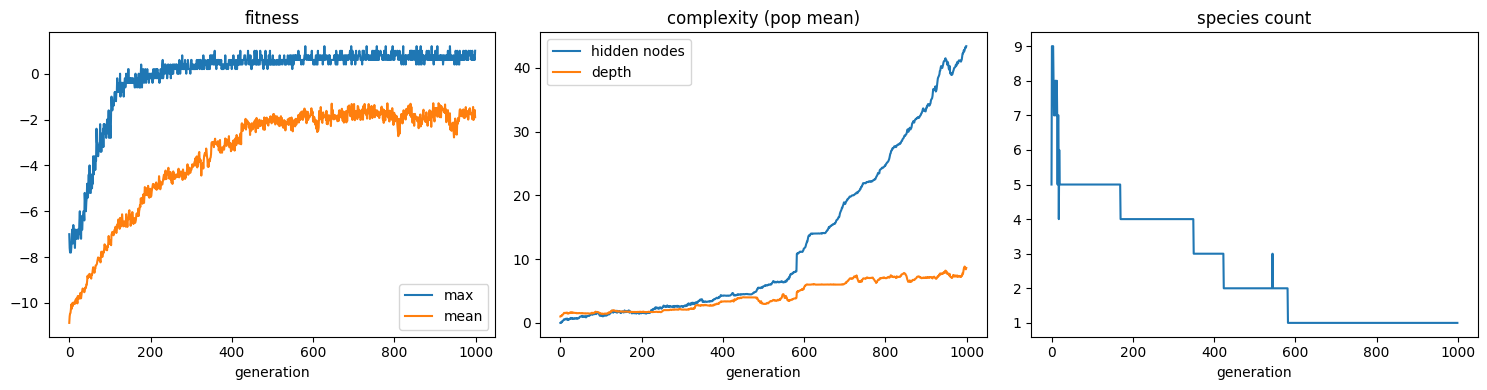

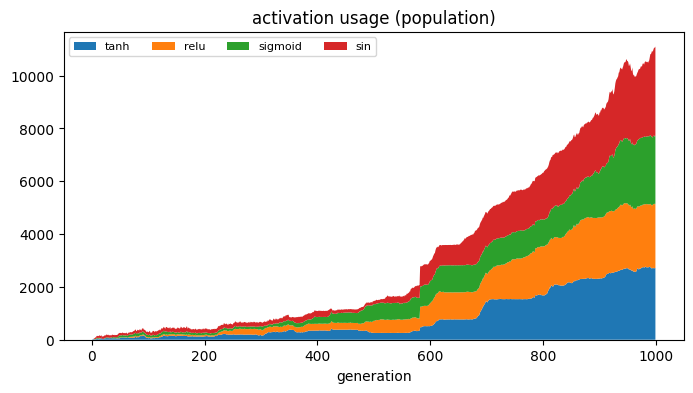

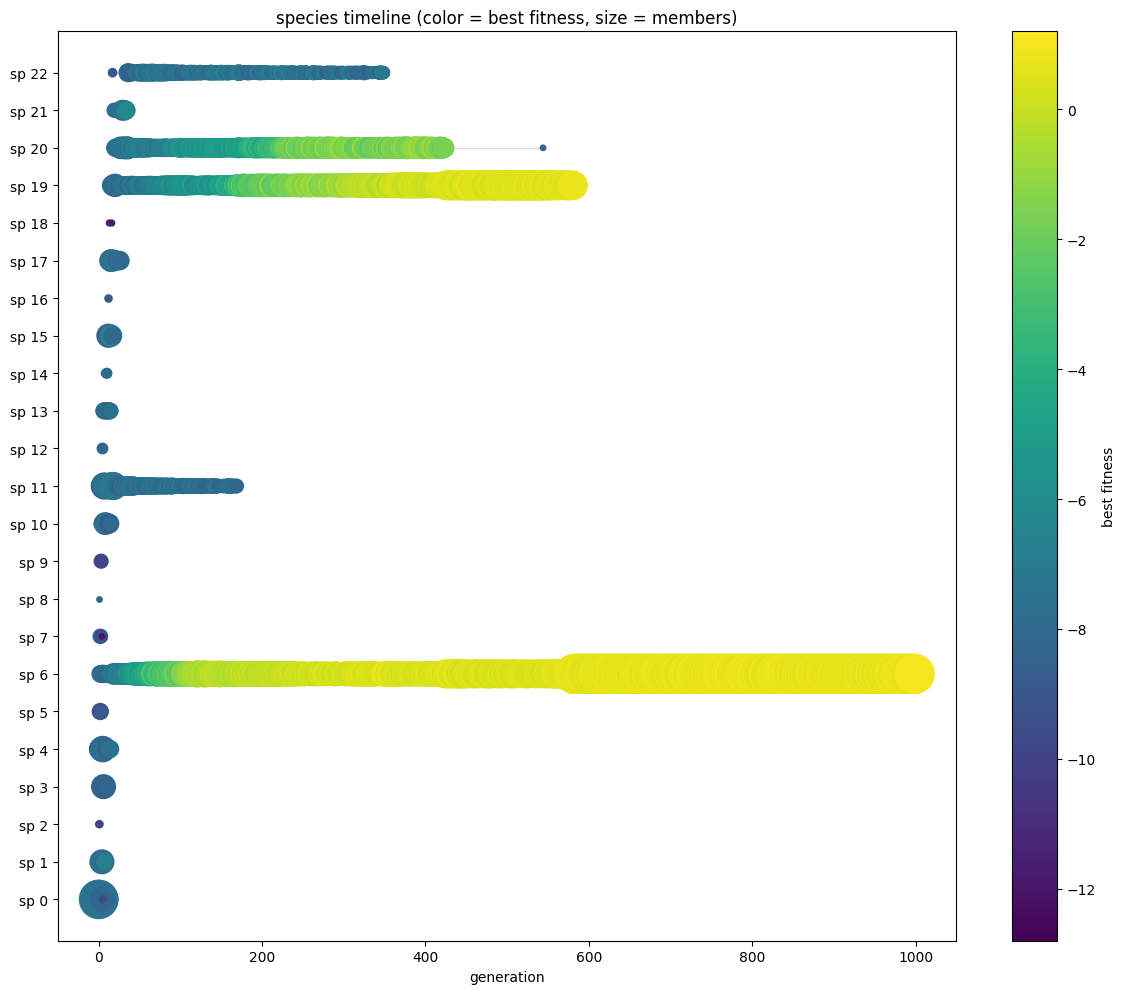

In [1]:
# %% [markdown]
# NEAT on Neural Slime Volleyball — Colab runner.
# Runtime > Change runtime type > GPU.

# %% Install dependencies and confirm a GPU is visible
!pip -q install evojax matplotlib networkx
import jax
print("devices:", jax.devices())          # expect a CudaDevice; if CPU, switch runtime to GPU

# %% Clone the library (SlimeVolley branch) and make it importable
!rm -rf Neuroevolution
!git clone -b SlimeVolley https://github.com/yugoguy/Neuroevolution.git
import sys
sys.path.append("/content/Neuroevolution")

# %% Hyperparameters
#@markdown ### Run
pop_size = 256          #@param {type:"integer"}
num_generations = 1000   #@param {type:"integer"}
n_max = 64              #@param {type:"integer"}
seed = 0                #@param {type:"integer"}
verbose = True          #@param {type:"boolean"}

#@markdown ### Network / forward pass
num_passes = 64                 #@param {type:"integer"}
output_activation = "tanh"      #@param ["tanh","relu","sigmoid","sin"]
new_node_activation = "random"  #@param ["random","tanh","relu","sigmoid","sin"]

#@markdown ### Initialization
weight_init_std = 1.0   #@param {type:"number"}

#@markdown ### Mutation
p_weight = 0.8          #@param {type:"number"}
perturb_std = 0.1       #@param {type:"number"}
replace_prob = 0.001      #@param {type:"number"}
p_add_connection = 0.009  #@param {type:"number"}
p_add_node = 0.009       #@param {type:"number"}
p_activation = 0.005      #@param {type:"number"}
add_conn_max_tries = 20 #@param {type:"integer"}

#@markdown ### Crossover
reenable_prob = 0.025            #@param {type:"number"}
inherit_from_fitter_prob = 0.9  #@param {type:"number"}
interspecies_mating_prob = 0.001 #@param {type:"number"}

#@markdown ### Speciation
compat_threshold = 0.475      #@param {type:"number"}
c_unmatched = 1.0           #@param {type:"number"}
c_weight = 0.4              #@param {type:"number"}
normalize_threshold = 0    #@param {type:"integer"}
rep_selection = "random"    #@param ["random","first"]

#@markdown ### Reproduction
survival_threshold = 0.2        #@param {type:"number"}
elitism_min_species_size = 2    #@param {type:"integer"}
mutate_only_prob = 0.3         #@param {type:"number"}
parent_selection = "uniform"    #@param ["uniform","fitness_weighted"]
max_stagnation = 100             #@param {type:"integer"}
population_stall = 100            #@param {type:"integer"}

#@markdown ### Evaluation
max_steps = 1000            #@param {type:"integer"}
episodes_per_genome = 5     #@param {type:"integer"}
eval_batch_size = 0         #@param {type:"integer"}
eval_test_mode = False      #@param {type:"boolean"}
survival_weight = 0       #@param {type:"number"}
action_threshold = 0.0      #@param {type:"number"}

from config import Config
cfg = Config(
    pop_size=pop_size, num_generations=num_generations, n_max=n_max, seed=seed, verbose=verbose,
    num_passes=num_passes, output_activation=output_activation, new_node_activation=new_node_activation,
    weight_init_std=weight_init_std,
    p_weight=p_weight, perturb_std=perturb_std, replace_prob=replace_prob,
    p_add_connection=p_add_connection, p_add_node=p_add_node, p_activation=p_activation,
    add_conn_max_tries=add_conn_max_tries,
    reenable_prob=reenable_prob, inherit_from_fitter_prob=inherit_from_fitter_prob,
    interspecies_mating_prob=interspecies_mating_prob,
    compat_threshold=compat_threshold, c_unmatched=c_unmatched, c_weight=c_weight,
    normalize_threshold=normalize_threshold, rep_selection=rep_selection,
    survival_threshold=survival_threshold, elitism_min_species_size=elitism_min_species_size,
    mutate_only_prob=mutate_only_prob, parent_selection=parent_selection,
    max_stagnation=max_stagnation, population_stall=population_stall,
    max_steps=max_steps, episodes_per_genome=episodes_per_genome, eval_batch_size=eval_batch_size,
    eval_test_mode=eval_test_mode, survival_weight=survival_weight, action_threshold=action_threshold,
)

# %% Run evolution (first generation is slow due to JIT compilation)
from orchestrator import evolve
best, rec = evolve(cfg)
rec.dump_json("history.json")
print("best fitness:", rec.records[-1]["best"]["fitness"])

# %% Fitness, complexity, species over generations
import matplotlib.pyplot as plt
g = [r["gen"] for r in rec.records]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(g, [r["fitness"]["max"] for r in rec.records], label="max")
ax[0].plot(g, [r["fitness"]["mean"] for r in rec.records], label="mean")
ax[0].set_title("fitness"); ax[0].set_xlabel("generation"); ax[0].legend()
ax[1].plot(g, [r["complexity"]["hidden"]["mean"] for r in rec.records], label="hidden nodes")
ax[1].plot(g, [r["complexity"]["depth"]["mean"] for r in rec.records], label="depth")
ax[1].set_title("complexity (pop mean)"); ax[1].set_xlabel("generation"); ax[1].legend()
ax[2].plot(g, [r["species"]["count"] for r in rec.records])
ax[2].set_title("species count"); ax[2].set_xlabel("generation")
plt.tight_layout(); plt.show()

# %% Activation usage across the population over time
import numpy as np
names = list(cfg.activation_names)
usage = np.array([[r["activations_population"].get(n, 0) for n in names] for r in rec.records])
plt.figure(figsize=(8, 4))
plt.stackplot(g, usage.T, labels=names)
plt.legend(loc="upper left", ncol=4, fontsize=8)
plt.title("activation usage (population)"); plt.xlabel("generation"); plt.show()

# %% Best network topology
from viz import draw_network
from IPython.display import Image
draw_network(best, cfg.num_inputs, cfg.num_outputs, "best_topology.png")
Image("best_topology.png")

# %% Topology at several generations (complexification story)
from recorder import load_genome
for gi in [0, cfg.num_generations // 2, cfg.num_generations - 1]:
    if gi in rec.best_snapshots:
        draw_network(load_genome(rec.best_snapshots[gi]),
                     cfg.num_inputs, cfg.num_outputs, f"topo_gen{gi}.png")

# %% Render a match vs. the built-in opponent as a GIF
from converter import activation_ids
from viz import render_gif
render_gif(best, cfg.num_inputs, cfg.num_outputs, cfg.n_max,
           activation_ids(names), names, cfg.num_passes,
           "play.gif", max_steps=3000, seed=0, fps=30)
Image("play.gif")

# %% Species timeline (lifespans over generations; color = best fitness, size = members)
import matplotlib.pyplot as plt
from matplotlib import cm
records = rec.records

fit_lookup, size_lookup, species_gens = {}, {}, {}
for r in records:
    for sid, st in r["species"]["fitness"].items():
        sid = int(sid)
        fit_lookup[(r["gen"], sid)] = st["max"]
        size_lookup[(r["gen"], sid)] = st["size"]
        species_gens.setdefault(sid, []).append(r["gen"])

sids = sorted(species_gens)
all_fit = list(fit_lookup.values())
vmin, vmax = (min(all_fit), max(all_fit)) if all_fit else (0, 1)

fig, ax = plt.subplots(figsize=(12, 0.35 * len(sids) + 2))
for row, sid in enumerate(sids):
    gens = species_gens[sid]
    ax.plot([min(gens), max(gens)], [row, row], color="0.85", lw=1, zorder=1)
    sc = ax.scatter(gens, [row] * len(gens),
                    c=[fit_lookup[(g, sid)] for g in gens],
                    s=[12 + 3 * size_lookup[(g, sid)] for g in gens],
                    cmap="viridis", vmin=vmin, vmax=vmax, zorder=2)
ax.set_yticks(range(len(sids))); ax.set_yticklabels([f"sp {s}" for s in sids])
ax.set_xlabel("generation"); ax.set_title("species timeline (color = best fitness, size = members)")
fig.colorbar(sc, ax=ax, label="best fitness")
plt.tight_layout(); plt.show()

# # %% Interactive explorer: pick a species + generation -> its best network + stats
# import ipywidgets as widgets
# from IPython.display import Image, display
# from recorder import load_genome
# from viz import draw_network

# def explore(species_id, generation):
#     snap = rec.species_best_snapshots.get(generation, {})
#     if species_id not in snap:
#         print(f"species {species_id} did not exist at generation {generation}")
#         return
#     st = records[generation]["species"]["fitness"][species_id]
#     print(f"species {species_id} @ gen {generation} — "
#           f"size {st['size']}, best {st['max']:.2f}, mean {st['mean']:.2f}")
#     draw_network(load_genome(snap[species_id]), cfg.num_inputs, cfg.num_outputs, "sp_best.png")
#     display(Image("sp_best.png"))

# widgets.interact(
#     explore,
#     species_id=widgets.Dropdown(options=sids, description="species"),
#     generation=widgets.IntSlider(min=0, max=len(records) - 1, step=1, value=len(records) - 1,
#                                  description="gen"),
# )